In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(tidyverse)
library(cowplot)
library(readr)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://con

In [2]:
od_tp <- read_tsv("od600_tp.tsv")
head(od_tp)
tail(od_tp)

Rows: 36 Columns: 4
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Carbon
dbl (2): Time_hr, OD600

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Time_hr,Strain,Carbon,OD600
<dbl>,<chr>,<chr>,<dbl>
0,51,M9_GLU,0.057
0,51,M9_SIA,0.070
0,51,M9_GMP,0.058
0,51,M9,0.056
0,69,M9_GLU,0.100
0,69,M9_SIA,0.100


Time_hr,Strain,Carbon,OD600
<dbl>,<chr>,<chr>,<dbl>
24,69,M9_GMP,0.168
24,69,M9,0.204
24,KPA,M9_GLU,0.938
24,KPA,M9_SIA,0.437
24,KPA,M9_GMP,0.129
24,KPA,M9,0.124


`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 581.77”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 3”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 3”
Warning message in sqrt(sum.squares/one.delta):
“NaNs produced”
Warning message i

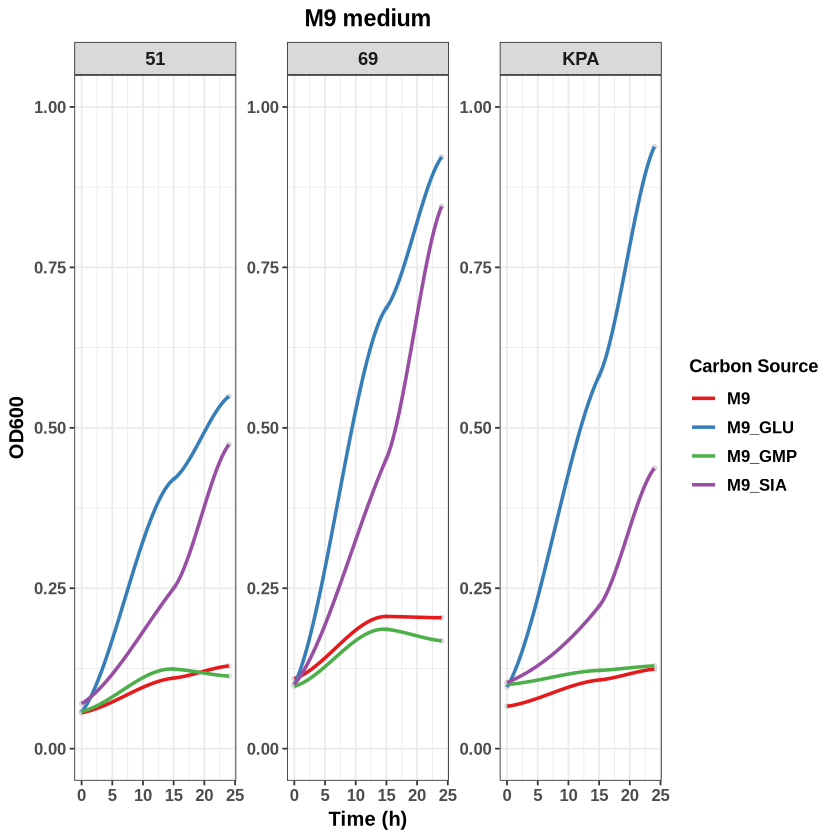

In [3]:
plotA <- ggplot(
  od_tp %>%
    filter(!is.na(Carbon), Carbon != "Blank"),   # remove blanks if present
  aes(x = Time_hr, y = OD600)
) +
  # Raw measurements in light gray
  geom_point(
    aes(group = interaction(Strain, Carbon)),
    color = "lightgray",
    size = 1.0,
    alpha = 0.7
  ) +
  # Loess trend colored by Carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 1,
    se = FALSE,
    linewidth = 1, 
    na.rm = TRUE
  ) +
  facet_wrap(~ Strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "M9 medium"
  ) +
  scale_y_continuous(limits = c(0, 1)) +   # same across all facets
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text  = element_text(face = "bold", size = 10),
    plot.title   = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA


In [4]:
ggsave("m9_acnes_anox_Nov19.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 581.77”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 3”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Chernobyl! trL>n 3”
Warning message in sqrt(sum.squares/one.delta):
“NaNs